### LSE Data Analytics Online Career Accelerator 

# DA301:  Advanced Analytics for Organisational Impact

## Assignment template

### Scenario
You are a data analyst working for Turtle Games, a game manufacturer and retailer. They manufacture and sell their own products, along with sourcing and selling products manufactured by other companies. Their product range includes books, board games, video games and toys. They have a global customer base and have a business objective of improving overall sales performance by utilising customer trends. In particular, Turtle Games wants to understand: 
- how customers accumulate loyalty points (Week 1)
- exploring the structure using decision trees (Week 2)
- exploring clusters in customer behaviour (Week 3)
- can social data (e.g. customer reviews) be used in marketing campaigns (Week 4)
- loading, transforming and visualising data in R (Week 5)
- statistical analysis and modelling in R (Week 6)

# Week 1 assignment: Linear regression using Python
The marketing department of Turtle Games prefers Python for data analysis. As you are fluent in Python, they asked you to assist with data analysis of social media data. The marketing department wants to better understand how users accumulate loyalty points. Therefore, you need to investigate the possible relationships between the loyalty points, age, remuneration, and spending scores. Note that you will use this data set in future modules as well and it is, therefore, strongly encouraged to first clean the data as per provided guidelines and then save a copy of the clean data for future use.

## Instructions
1. Load and explore the data.
    1. Create a new DataFrame (e.g. reviews).
    2. Sense-check the DataFrame.
    3. Determine if there are any missing values in the DataFrame.
    4. Create a summary of the descriptive statistics.
2. Remove redundant columns (`language` and `platform`).
3. Change column headings to names that are easier to reference (e.g. `renumeration` and `spending_score`).
4. Save a copy of the clean DataFrame as a CSV file. Import the file to sense-check.
5. Use linear regression and goodness of fit metrics to evaluate possible linear relationships between loyalty points and age/renumeration/spending scores to determine whether these can be used to predict the loyalty points.
    1. Specify the independent and dependent variables.
    2. Create the OLS model.
    3. Extract the estimated parameters, standard errors, and predicted values.
    4. Generate the regression table based on the X coefficient and constant values.
    5. Plot the linear regression and add a regression line.
6. Include your insights and observations.

## 1. Load and explore the data

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.formula.api import ols

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [154]:
# Load the CSV file(s) as reviews.

reviews = pd.read_csv('turtle_reviews.csv')

# View the DataFrame.
reviews.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [155]:
# Any missing values?
reviews.isnull().sum()

gender                    0
age                       0
remuneration (k£)         0
spending_score (1-100)    0
loyalty_points            0
education                 0
language                  0
platform                  0
product                   0
review                    0
summary                   0
dtype: int64

In [156]:
# Explore the data.

# Explore datatypes
reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform                2000 non-null   object 
 8   product                 2000 non-null   int64  
 9   review                  2000 non-null   object 
 10  summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB


In [157]:
# Basic descriptive statistics

# Explore the summary statistics of the dataset
reviews.describe()

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


## 2. Drop columns

In [158]:
# Drop unnecessary columns.
reviews = reviews.drop(columns=['language', 'platform']) 

# View column names.
reviews.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


## 3. Rename columns

In [159]:
# Rename the column headers.
reviews = reviews.rename(columns={
    'remuneration (k£)':'remuneration',
    'spending_score (1-100)': 'spending_score'
})

# View column names.
reviews.head()

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


## 4. Save the DataFrame as a CSV file

In [160]:
# Create a CSV file as output.
reviews.to_csv('clean_reviews.csv', index=False)

In [161]:
# Import new CSV file with Pandas.
clean_df = pd.read_csv('clean_reviews.csv')

# View DataFrame.
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          2000 non-null   object 
 1   age             2000 non-null   int64  
 2   remuneration    2000 non-null   float64
 3   spending_score  2000 non-null   int64  
 4   loyalty_points  2000 non-null   int64  
 5   education       2000 non-null   object 
 6   product         2000 non-null   int64  
 7   review          2000 non-null   object 
 8   summary         2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


## 5. Linear regression

### 5a) spending vs loyalty

In [30]:
# Define independent variable.
X = reviews[['spending_score']]

# Define dependent variable.
y = reviews['loyalty_points']

# Create model and print summary of metrics.
# Using statmodels.api as sm
# This also adds the intercept
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):          2.92e-263
Time:                        02:15:43   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -75.0527     45.931     -1.

In [34]:
# Extract the estimated parameters.
model.params 



const            -75.052663
spending_score    33.061693
dtype: float64

In [33]:
# Extract the predicted values.
y_pred = model.predict(X_sm)

y_pred.head()

0    1214.353374
1    2602.944491
2     123.317497
3    2470.697718
4    1247.415067
dtype: float64

In [35]:
# Extract the standard errors.
model.bse

const             45.930554
spending_score     0.814419
dtype: float64

In [36]:
# Set the X coefficient and the constant to generate the regression table.

# Extract Co-efficient and the Intercept.
intercept = model.params['const']
slope = model.params['spending_score']

# View the output
print('Intercept:', intercept)
print('Slope:', slope)


Intercept: -75.05266293364824
Slope: 33.06169325867293


In [37]:
# Generate predicted values
reviews['predicted_loyalty_points'] = intercept + slope * reviews['spending_score']

In [39]:
# Create regression table
regression_table = pd.DataFrame({
    'Actual': reviews['loyalty_points'],
    'Predicted': reviews['predicted_loyalty_points']
})
print(regression_table.head())

   Actual    Predicted
0     210  1214.353374
1     524  2602.944491
2      40   123.317497
3     562  2470.697718
4     366  1247.415067


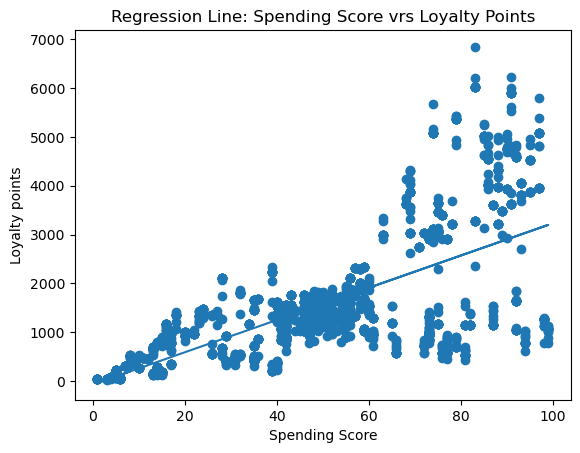

In [41]:
# Plot the graph with a regression
# Scatter plot (actual data)
plt.scatter(reviews['spending_score'], reviews['loyalty_points'])

# Regression line
plt.plot(
    reviews['spending_score'],
    reviews['predicted_loyalty_points']
)

plt.xlabel('Spending Score')
plt.ylabel('Loyalty points')
plt.title('Regression Line: Spending Score vrs Loyalty Points')
plt.show()

**OBSERVATIONS**
  
Observations from regression analysis of spending score (X) on loyalty points (y).
- The regression model shows a significant positive relationship between spending score and loyalty points.
Therefore, spending score is a reliable predictor of loyalty points.
- The coefficient (beta = 33.06) indicates that a one unit increase in spending score increases loyalty points by 
approximately 33 units.
- The model is statistically significant(F = 1648, p < 0.001).
- The R-squared value of 0.452 suggests that 45.2% of the variation in loyalty points is explained by spending score.
Thisis moderate predictive power.
- The predictor is statistically significant (p < 0.05) while the intercept is not.
- The standard error, which indicates reliability is (0.814) for spending score. This is small error compared to the 
co-efficient of 33. Therefore this estimate seem quite precise.


### 5b) renumeration vs loyalty

In [47]:
# Define independent variable.
X = reviews[['remuneration']]

# Define dependent variable.
y = reviews['loyalty_points']

# Create model and print summary of metrics.
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1222.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):          2.43e-209
Time:                        17:19:35   Log-Likelihood:                -16674.
No. Observations:                2000   AIC:                         3.335e+04
Df Residuals:                    1998   BIC:                         3.336e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -65.6865     52.171     -1.259   

In [51]:
# Extract the estimated parameters.
model.params

# Extract the standard errors.
model.bse

# Extract the predicted values.
y_pred = model.predict(X_sm)

y_pred

0       1664.287247
1       1644.223221
2       1648.236026
3       1636.197611
4       1604.095169
           ...     
1995    1588.043949
1996    1563.967118
1997    1600.082364
1998    1600.082364
1999    1608.107975
Length: 2000, dtype: float64

In [48]:
# Set the the X coefficient and the constant to generate the regression table.
# Extract Co-efficient and the Intercept.
intercept = model.params['const']
slope = model.params['remuneration']

# View the output
print('Intercept:', intercept)
print('Slope:', slope)



# Generate predicted values
reviews['predicted_loyalty_points'] = intercept + slope * reviews['remuneration']

# Create regression table
regression_table = pd.DataFrame({
    'Actual': reviews['loyalty_points'],
    'Predicted': reviews['predicted_loyalty_points']
})
print(regression_table.head())

Intercept: -65.68651279499333
Slope: 34.1878254856687
   Actual   Predicted
0     210  354.823741
1     524  354.823741
2      40  382.857758
3     562  382.857758
4     366  410.891774


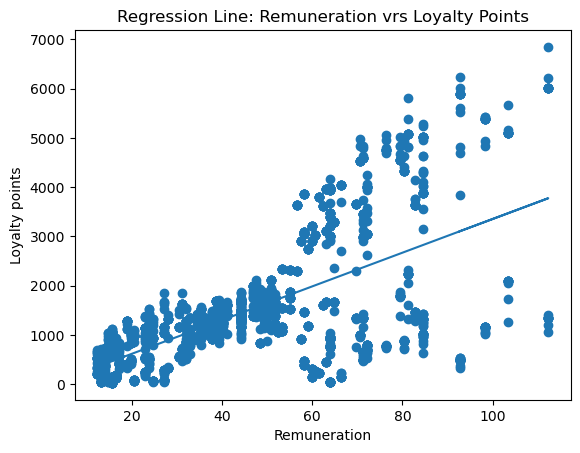

In [49]:
# Plot graph with regression line.
# Scatter plot (actual data)
plt.scatter(reviews['remuneration'], reviews['loyalty_points'])

# Regression line
plt.plot(
    reviews['remuneration'],
    reviews['predicted_loyalty_points']
)

plt.xlabel('Remuneration')
plt.ylabel('Loyalty points')
plt.title('Regression Line: Remuneration vrs Loyalty Points')
plt.show()

### 5c) age vs loyalty

In [50]:
# Define independent variable.
X = reviews[['age']]

# Define dependent variable.
y = reviews['loyalty_points']

# Create model and print summary of metrics.
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.606
Date:                Fri, 17 Apr 2026   Prob (F-statistic):             0.0577
Time:                        17:45:43   Log-Likelihood:                -17150.
No. Observations:                2000   AIC:                         3.430e+04
Df Residuals:                    1998   BIC:                         3.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1736.5177     88.249     19.678      0.0

In [52]:
# Extract the estimated parameters.
# Extract the estimated parameters.
model.params

# Extract the standard errors.
model.bse

# Extract the predicted values.
y_pred = model.predict(X_sm)

y_pred


0       1664.287247
1       1644.223221
2       1648.236026
3       1636.197611
4       1604.095169
           ...     
1995    1588.043949
1996    1563.967118
1997    1600.082364
1998    1600.082364
1999    1608.107975
Length: 2000, dtype: float64

In [53]:
# Set the X coefficient and the constant to generate the regression table.

# Extract Co-efficient and the Intercept.
intercept = model.params['const']
slope = model.params['age']

# View the output
print('Intercept:', intercept)
print('Slope:', slope)



# Generate predicted values
reviews['predicted_loyalty_points'] = intercept + slope * reviews['age']

# Create regression table
regression_table = pd.DataFrame({
    'Actual': reviews['loyalty_points'],
    'Predicted': reviews['predicted_loyalty_points']
})
print(regression_table.head())


Intercept: 1736.5177393990616
Slope: -4.012805149995196
   Actual    Predicted
0     210  1664.287247
1     524  1644.223221
2      40  1648.236026
3     562  1636.197611
4     366  1604.095169


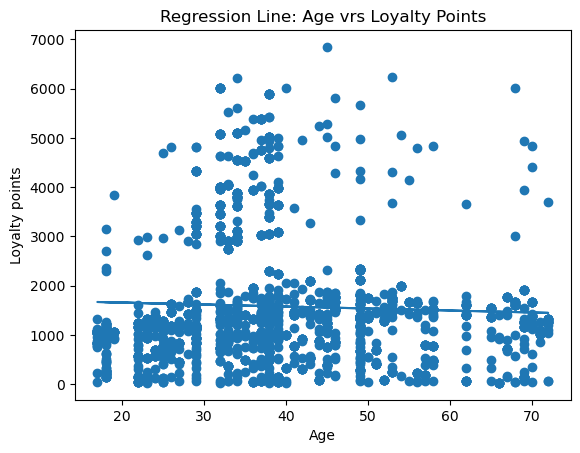

In [54]:
# Plot graph with regression line.
# Scatter plot (actual data)
plt.scatter(reviews['age'], reviews['loyalty_points'])

# Regression line
plt.plot(
    reviews['age'],
    reviews['predicted_loyalty_points']
)

plt.xlabel('Age')
plt.ylabel('Loyalty points')
plt.title('Regression Line: Age vrs Loyalty Points')
plt.show()

## 6. Observations and insights

***Your observations here...***






**Remuneration vrs Loyalty Points**

- There is relatively strong, positive, and statistically significant relationship between remuneration and loyalty points.
One unit increase in remuneration is associated with an average increase of approximately 34 loyalty points.
- The model explains 38% variation in loyalty points by the R-squared.This indicates moderate explanatory power.
- The confidence interval is positive and narrow (32.27 - 36.11).
- Overall the model is highly significant (F-statistic = 1222 and Prob(F-statistic = 2.43e-209). This implies that 
remuneration is an important predictor of loyalty point but additional variables are needed to fully 
explain the variation in loyalty outcomes.

**Age vrs Loyalty Points**

- R-squared = 0.002. This indicates that only 0.2% of variation in loyalty points is explained by Age. This is extremely weak.
- Adjusted R-squared = 0.001. This indicates that the model has no explanatory power.
- The F-statistic p-value = 0.0577. This is slightly above 0.05. This indicates that the model is not statistically significant at 5% level. This shows weak evidence that any relationship exists at all. Also confirmed by the graph plot.
- Overall, the model is not useful for prediction or strong decision-making. One can not confidently say age affects loyalty points.

**Key Insights**
- Spending Score model is the strongest predictor of customer loyalty. It explains 45.2% of loyalty points. Spending behavoiur is a major driver of loyalty.
- Remuneration model is also strong but weaker than Spending Score model. It explains 38% of loyalty points. Higher income may translate into higher loyalty points. Income matters but actual spending behaviour matters more.
- Age model is weak or not reliable. Age does not meaningfully influence loyalty.
- Spending which is a customer behaviour is a more powerful predictor of loyalty than demographics.

**Marketing Priorities & Decisions**
- Target high spending behaviour. Some actions may include creating loyalty tiers based on spending_score and also offer exclusive rewards, premium perks etc.
- Identify high income customers and offer premium products, luxury bundles/combos. But because income is not actual behaviour, it must be linked to spending_score:
    - High spending + high income = treat as VIP
    - High spending + low income = reward (discounts) and retain
    - Low spending + high income = upsell
    - Low spending + low income = low priority and mass marketing
- Avoid age-based marketing strategies such as segmenting by age groups. This is not supported by the data and it is weak and unreliable.

# Week 2 assignment: Exploring the structure using decision trees.

The team wants you to use decision trees to attempt to better understand the structure found in the data. You need to grow and prune a decision tree regressor and then visualise and interpret the output.
Make sure to comment on the potential usefulness in decision-making processes and your observations regarding the model.

## Instructions
1. Prepare the data for creating your decision tree. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame with the appropriate columns.
        1. Specify that loyalty points is the target variable (Y) and should be excluded from your input data.
        2. Specify X for the independent variables and y as the dependent variable. Therefore, df\[cols\] will be the independent variables and the column containing loyalty points the dependent variable.
        3. Explore the new DataFrame. 
2. Split the data set into a train and test sets for both X and y at a 70:30 ratio. As previously, random_state=42.
3. Create a decision tree regressor to explore the impact of other features on the loyalty points.
    1. Import the DecisionTreeRegressor class from the sklearn.tree library. 
    2. Create a variable (e.g. regressor) to store the DecisionTreeRegressor() class. (As previously, random_state=42.).
    3. Fit the regressor object to the data set with the fit() function.
    4. Remember to prune your tree using basic pruning strategies and compare the performance before and after applying the pruning strategy.
    5. Plot the final decision tree.
4. Fit a final model and interpret the output.
    1. Justify your selection of pruning strategy implemented and interpret the output.
    2. Evaluate the usefulness of the obtained result and interpret the tree and how it could be used to inform business decisions in the organisation.
5. Summarise (150–200 words) the most important business insights, anything you would like to explore further, and suggested future actions.
 
Back up your work to a safe location. This will allow you to revert to a previous state in the case of making a mistake in the code or deleting a section by mistake. (A simple way of doing this is to save or email a compressed version to yourself at frequent intervals.)


## 1. Load and prepare the data

In [1]:
# Import all the necessary packages
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree 
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# plot_confusion_,atrix is deprecated


# Settings for the notebook.
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [15, 10]

In [11]:
# Create your new DataFrame.

df2 = pd.read_csv('clean_reviews.csv')

# Explore new data frame
df2.head()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          2000 non-null   object 
 1   age             2000 non-null   int64  
 2   remuneration    2000 non-null   float64
 3   spending_score  2000 non-null   int64  
 4   loyalty_points  2000 non-null   int64  
 5   education       2000 non-null   object 
 6   product         2000 non-null   int64  
 7   review          2000 non-null   object 
 8   summary         2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


In [36]:
# Specify Y.
y = df2['loyalty_points']

# Specify X.
X = df2.drop(columns=['loyalty_points', 'review', 'summary'])

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [37]:
# Review X and Y.
print(X.head())
print(y.head())


   age  remuneration  spending_score  product  gender_Male  education_PhD  \
0   18         12.30              39      453         True          False   
1   23         12.30              81      466         True          False   
2   22         13.12               6      254        False          False   
3   25         13.12              77      263        False          False   
4   33         13.94              40      291        False          False   

   education_diploma  education_graduate  education_postgraduate  
0              False                True                   False  
1              False                True                   False  
2              False                True                   False  
3              False                True                   False  
4              False                True                   False  
0    210
1    524
2     40
3    562
4    366
Name: loyalty_points, dtype: int64


## 2. Create train and test data sets.

In [38]:
# Split the data into test and train data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## 3. Create Decision tree regressor

In [39]:
# Create your decision tree regressor.
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [40]:
# Evaluate the model.
y_pred = regressor.predict(X_test)

print('R2:', r2_score(y_test, y_pred))

# Had to compute RMSE manually
mse =mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print('RMSE:', rmse)

R2: 0.9937044218103145
RMSE: 100.98296060887368


In [41]:
# Prune the model.
# Prune using Cost Complexity Pruning
path = regressor.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Train multiple trees
regressors = []
for alpha in ccp_alphas:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    regressors.append(model)

# Evaluate
r2_scores = []
for model in regressors:
    y_pred = model.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

# Find best alpha
best_alpha = ccp_alphas[r2_scores.index(max(r2_scores))]

print('Best alpha:', best_alpha)


Best alpha: 0.14291666666661124


## 4. Fit and plot final model.

In [42]:
# Fit and plot final model.
final_regressor = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha)
final_regressor.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

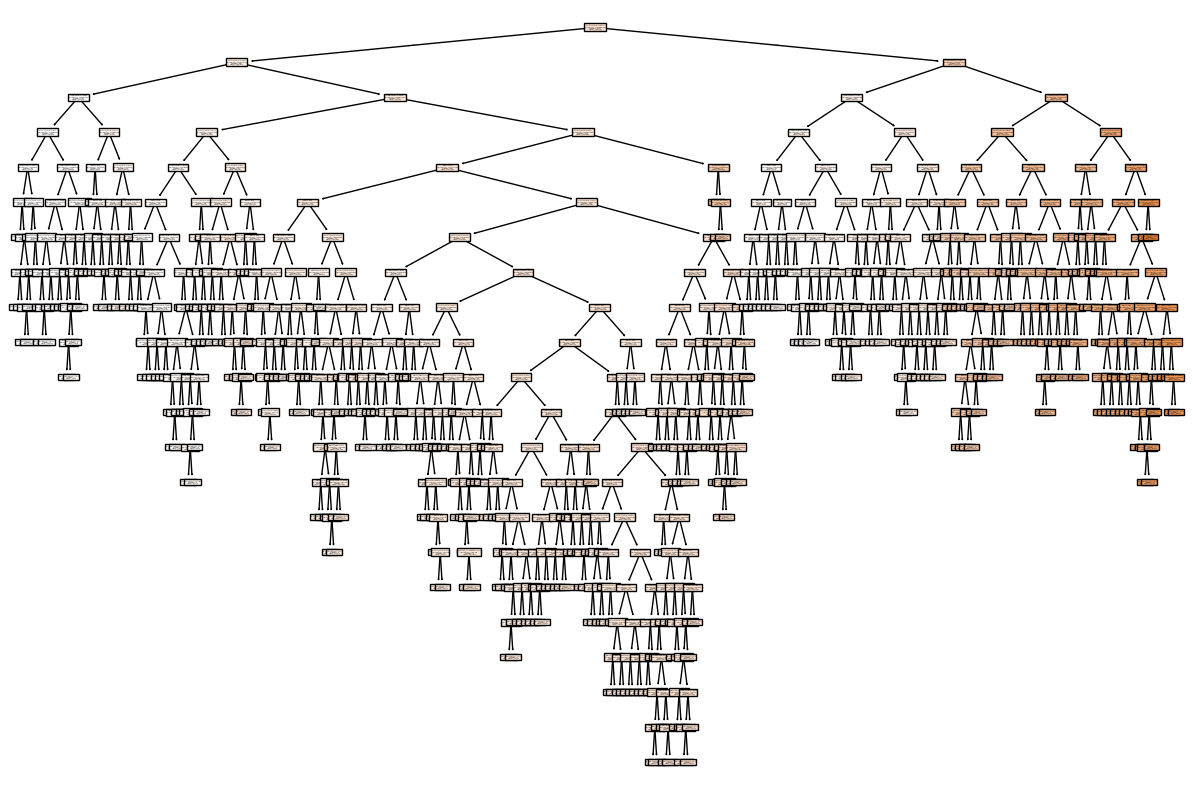

In [43]:
# Visualise the tree
plt.figure(figsize=(15,10))
plot_tree(final_regressor, feature_names=X.columns, filled=True)
plt.show()

## 5. Discuss: Insights and observations

***Your observations here...***

**Interpretation of the Model and Observation**

- R2: 0.9937 (=99.37%). This means the model explains 99% of the variability in loyalty points. 
On the face of it, it appears excellent but it is suspiciously high. This likely indicates overfitting especially 
with such a large tree. This suggests the model may not generalise well to unseen data.
- RMSE: 100.98. This may suggest moderate prediction error relative to the scale of loyalty points,
but the scale of loyalty points have not been given in the metadata making comparison difficult.
Best alpha: 0.1429. This indicates less aggressive pruning is needed as removing text has already helped to prune the tree.
While the model demonstrates excellent predictive performance, the complexity of the decision tree limits its interpretabilty.
Text variables such as 'reviews' and 'summary' were removed in order to reduce the complexity of the model,
The resulting decision tree remains hightly detailed and difficult to interpret, limiting its direct usefulness
for business decision-making. For the future, simpler models are preferred even at the cost of slight reductions in accuracy.

# 

# Week 3 assignment: Clustering with *k*-means using Python

The marketing department also wants to better understand the usefulness of renumeration and spending scores but do not know where to begin. You are tasked to identify groups within the customer base that can be used to target specific market segments. Use *k*-means clustering to identify the optimal number of clusters and then apply and plot the data using the created segments.

## Instructions
1. Prepare the data for clustering. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame (e.g. `df3`) containing the `renumeration` and `spending_score` columns.
    3. Explore the new DataFrame. 
2. Plot the renumeration versus spending score.
    1. Create a scatterplot.
    2. Create a pairplot.
3. Use the Silhouette and Elbow methods to determine the optimal number of clusters for *k*-means clustering.
    1. Plot both methods and explain how you determine the number of clusters to use.
    2. Add titles and legends to the plot.
4. Evaluate the usefulness of at least three values for *k* based on insights from the Elbow and Silhoutte methods.
    1. Plot the predicted *k*-means.
    2. Explain which value might give you the best clustering.
5. Fit a final model using your selected value for *k*.
    1. Justify your selection and comment on the respective cluster sizes of your final solution.
    2. Check the number of observations per predicted class.
6. Plot the clusters and interpret the model.

## 1. Load and explore the data

In [53]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

In [44]:
# Load the CSV file(s) as df2.
df2 = pd.read_csv('clean_reviews.csv')

# View DataFrame.
df2.head()

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [45]:
# Drop unnecessary columns.
df3 = df2[['remuneration', 'spending_score']]

# View DataFrame.
df3.head()

,remuneration,spending_score
0,12.30,39
1,12.30,81
2,13.12,6
3,13.12,77
4,13.94,40


In [46]:
# Explore the data.
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   remuneration    2000 non-null   float64
 1   spending_score  2000 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


In [47]:
# Descriptive statistics.
df3.describe()

,remuneration,spending_score
count,2000.000000,2000.000000
mean,48.079060,50.000000
std,23.123984,26.094702
min,12.300000,1.000000
25%,30.340000,32.000000
50%,47.150000,50.000000
75%,63.960000,73.000000
max,112.340000,99.000000


## 2. Plot

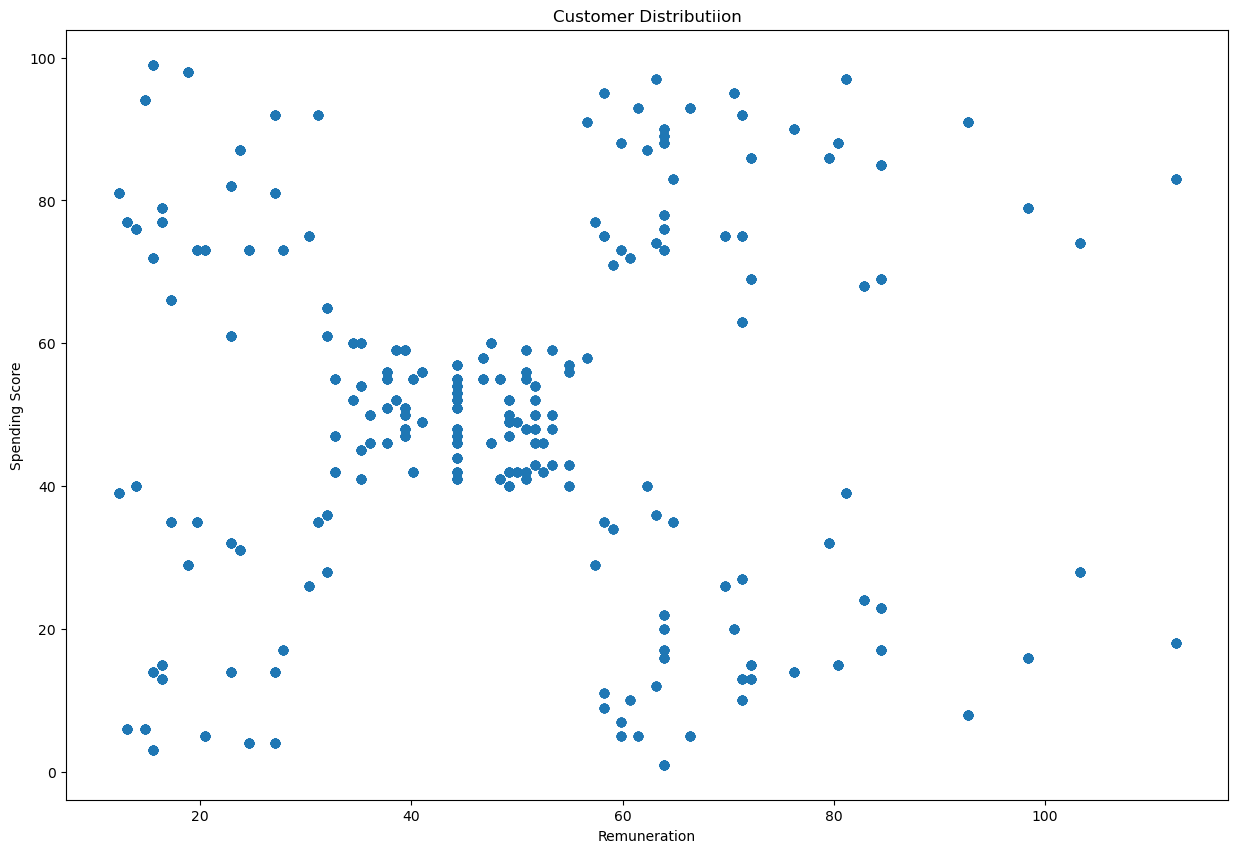

In [51]:
# Create a scatterplot with Seaborn.
plt.scatter(df3['remuneration'], df3['spending_score'])
plt.xlabel('Remuneration')
plt.ylabel('Spending Score')
plt.title('Customer Distributiion')
plt.show()

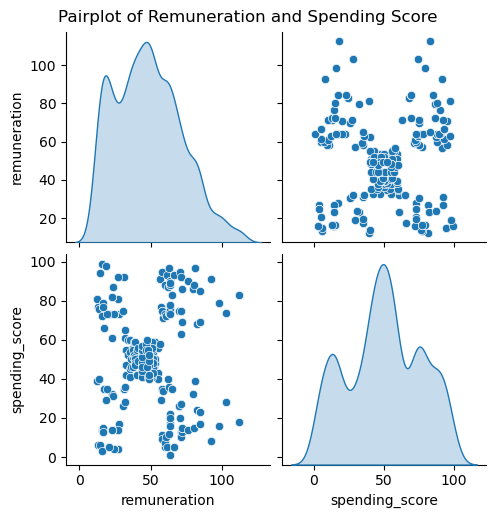

In [55]:
# Create a pairplot with Seaborn.
sns.pairplot(df3[['remuneration', 'spending_score']], diag_kind='kde')
plt.suptitle('Pairplot of Remuneration and Spending Score', y=1.02)
plt.show()

## 3. Elbow and silhoutte methods

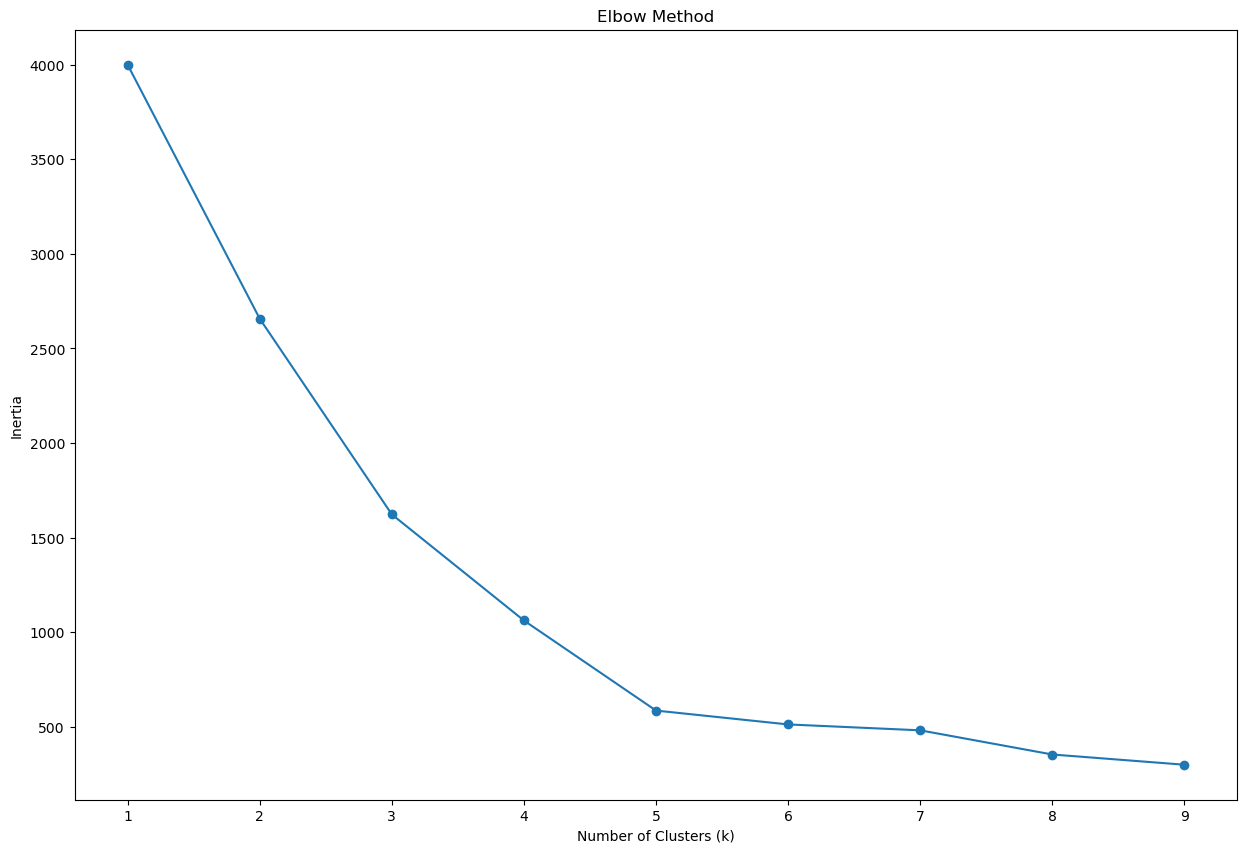

In [58]:
# Determine the number of clusters: Elbow method.
# First scale the data as k-means is distance-based
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df3)

# Elbow method to find the optimal K
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

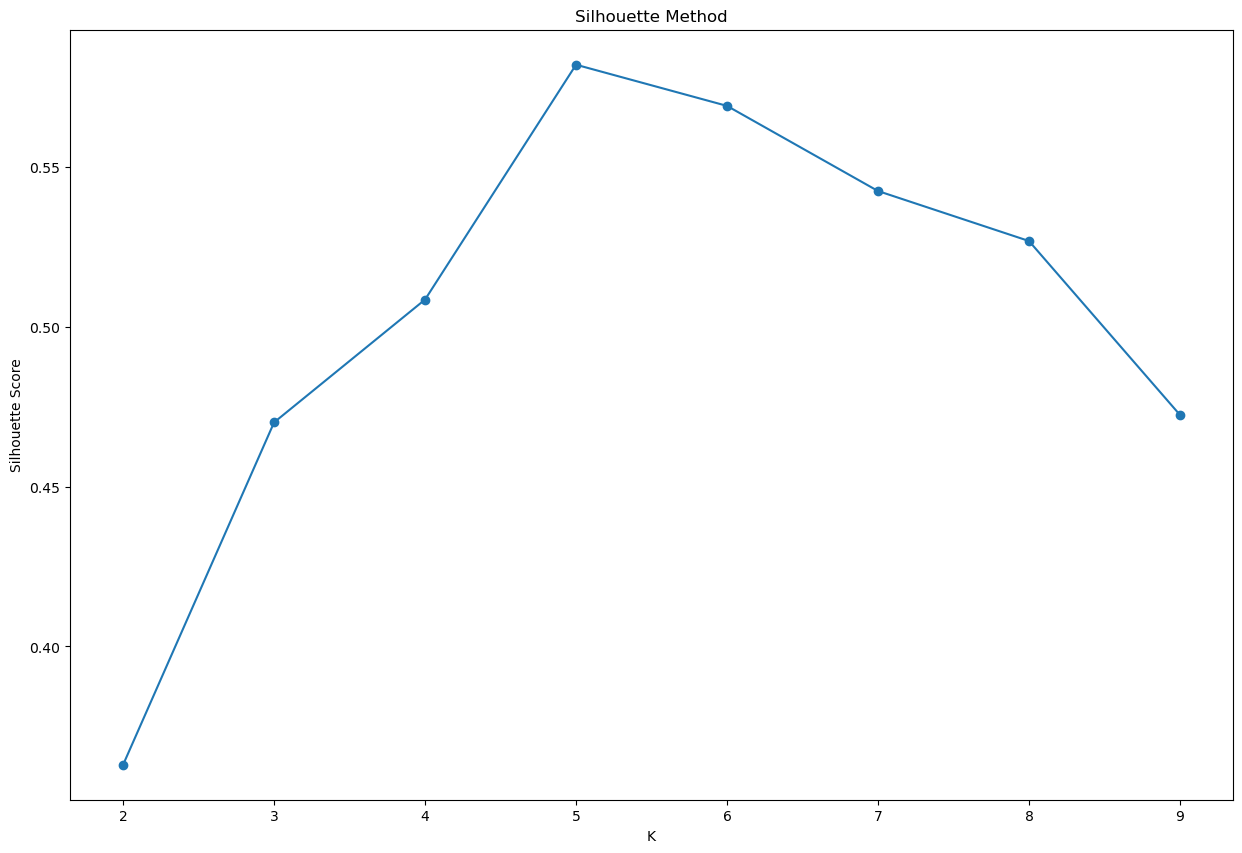

In [60]:
# Determine the number of clusters: Silhouette method.
# Silhouette method to confirm the K
sil_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    sil_scores.append(silhouette_score(df_scaled, labels))

plt.plot(range(2, 10), sil_scores, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

## 4. Evaluate k-means model at different values of *k*

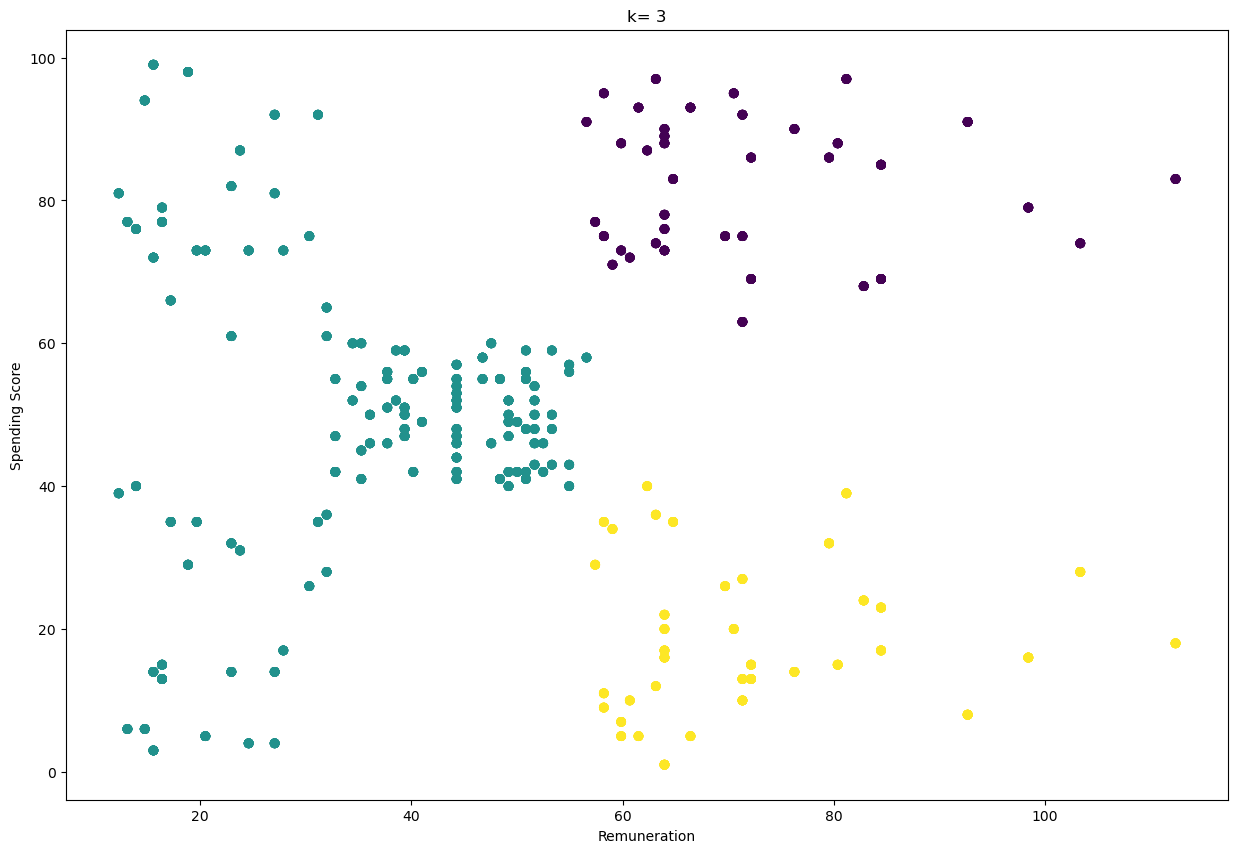

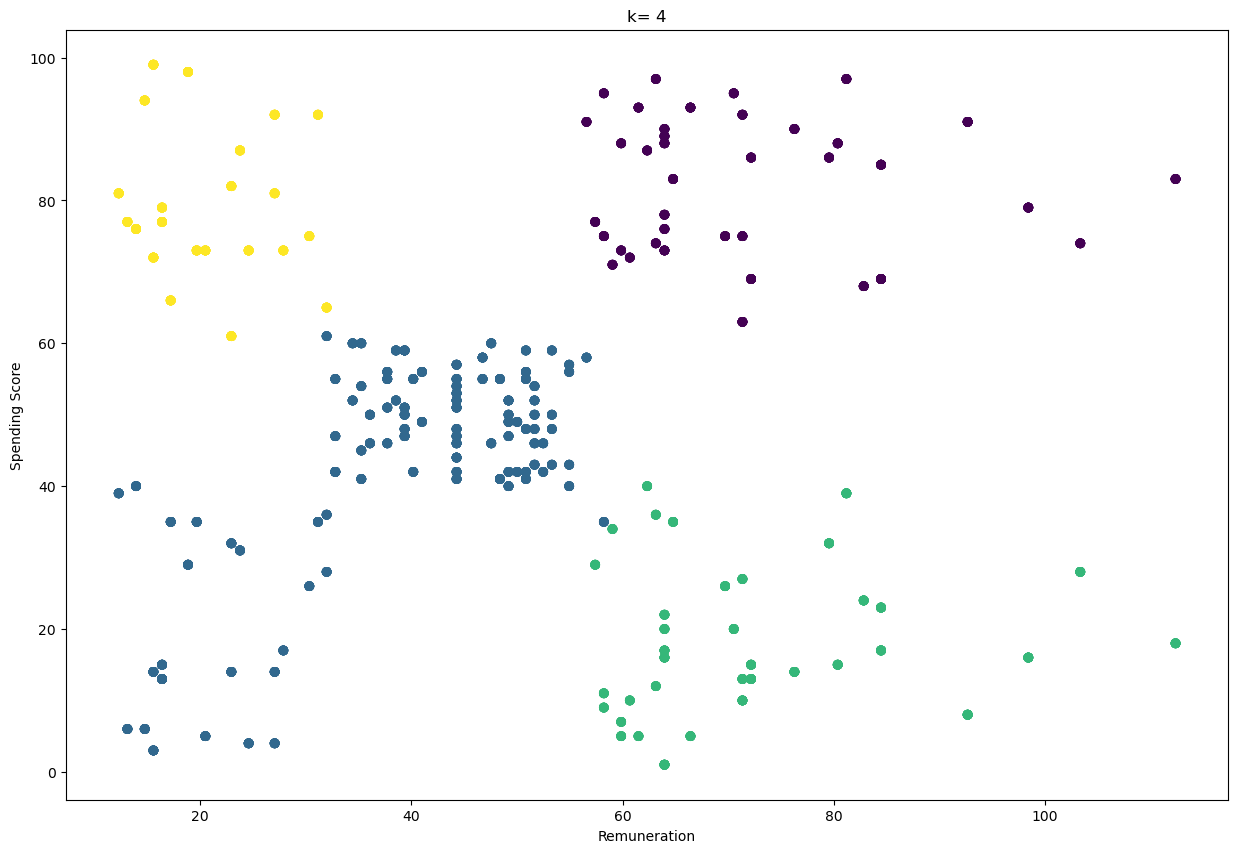

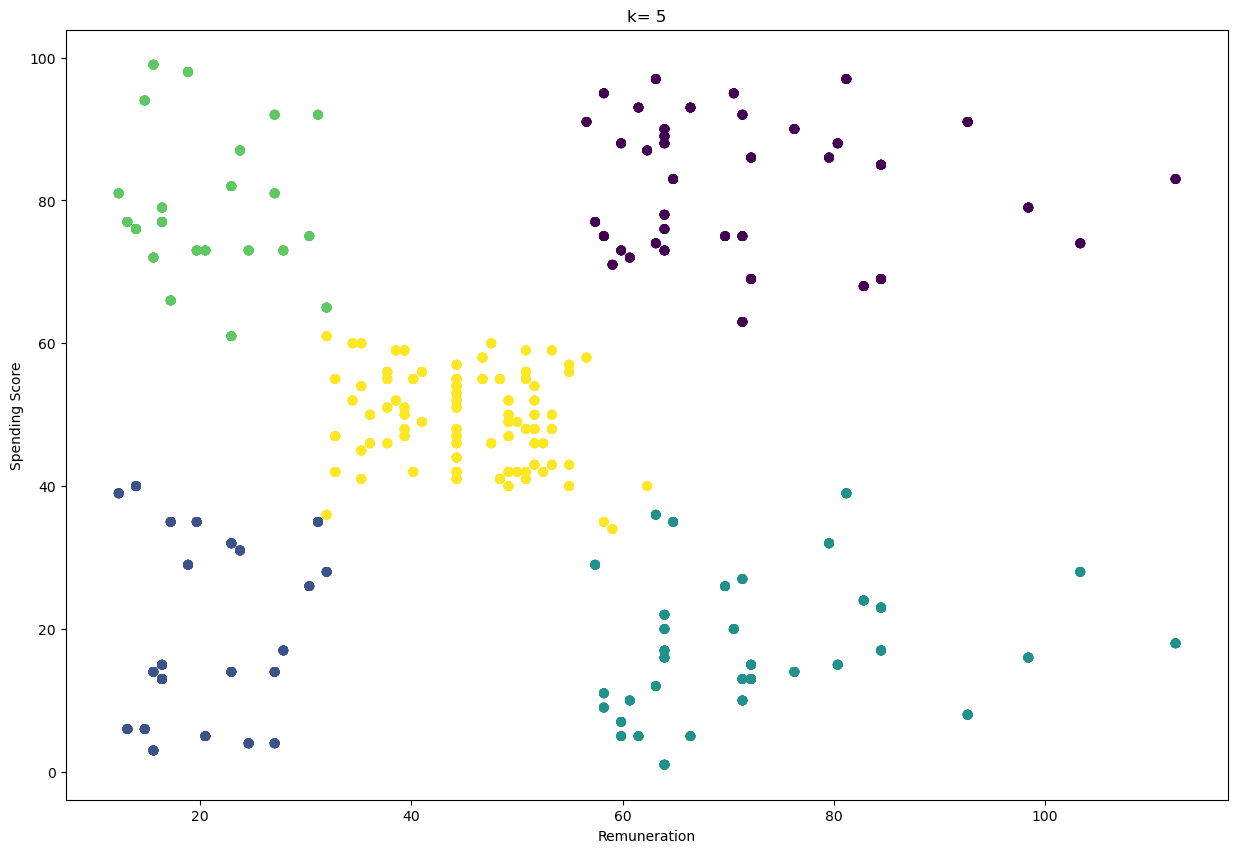

In [64]:
# Trying at least 3 values of K

for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)

    plt.scatter(df3['remuneration'], df3['spending_score'], c=labels)
    plt.title(f'k= {k}')
    plt.xlabel('Remuneration')
    plt.ylabel('Spending Score')
    plt.show()


    

## 5. Fit final model and justify your choice

In [67]:
# Apply the final model.
# From the visualisations, my chosen k=5. It is pretty obvious there are 5 clusters.
kmeans = KMeans(n_clusters=5, random_state=42)
df3['Cluster'] = kmeans.fit_predict(df_scaled)

In [68]:
# Check the number of observations per predicted class.
df3['Cluster'].value_counts()

Cluster
4    774
0    356
2    330
1    271
3    269
Name: count, dtype: int64

## 6. Plot and interpret the clusters

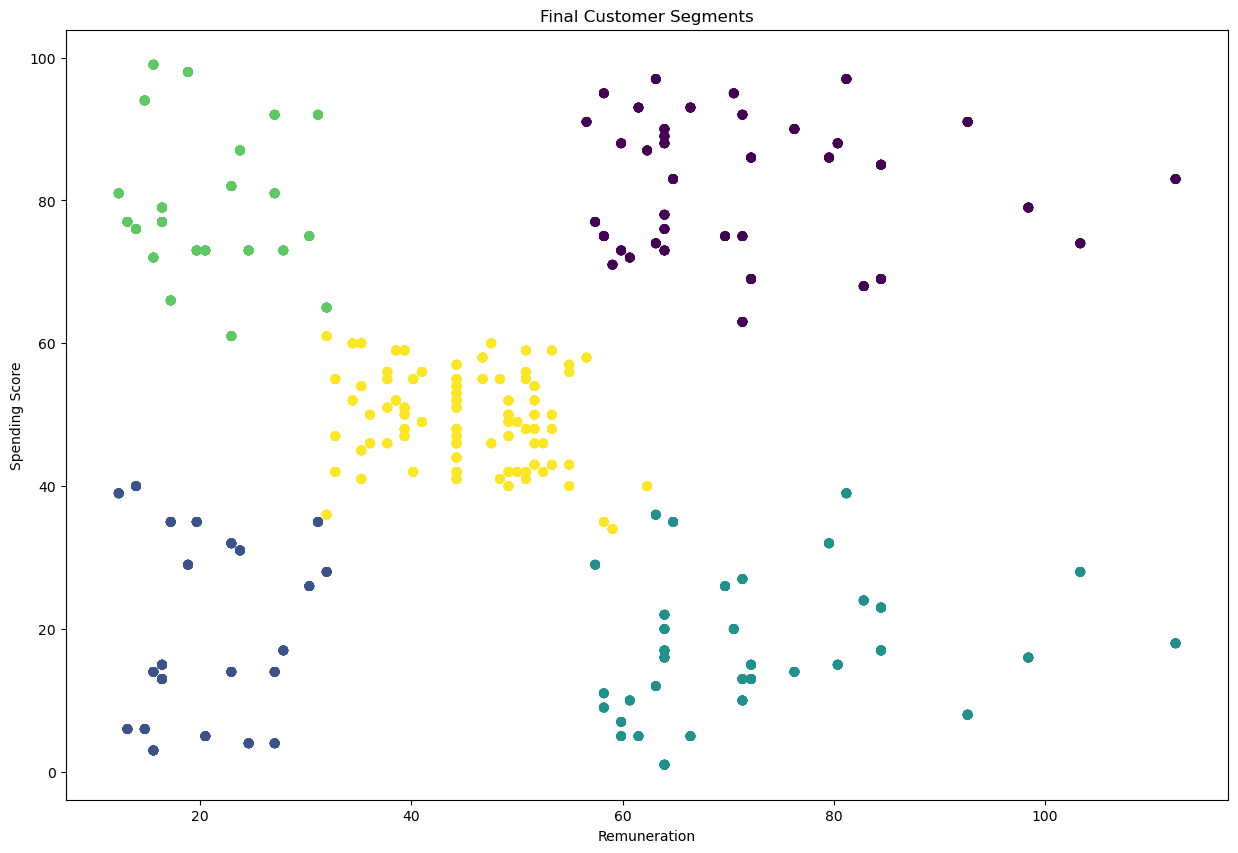

In [69]:
# Visualising the clusters.
plt.scatter(df3['remuneration'], df3['spending_score'], c=df3['Cluster'])
plt.xlabel('Remuneration')
plt.ylabel('Spending Score')
plt.title('Final Customer Segments')
plt.show()



## 7. Discuss: Insights and observations

***Your observations here...***

**Interpretation & Insights**

Five distinct clusters/customer groups identified:
- **Top Right:** These are high income, high spenders. These are premium customers. Business decision include loyalty rewards,
VIP programmes and exclusive offer.
- **Top Left:**: These are low income, high spenders. These are value seekers. Business decision include offering of discounts,
promotions and bundle deals.
- **Bottom Left:** These are low income, low spenders. This is low value group. Business decision include minimal spend on
marketing and cost-efficient enagegemnt with them.
- **Bottom Right:** These are high income, low spenders. This is underutilised with great potential group. Business decision include targeted campaigns and incentives to spend more.
- **Middle:** These are the core customers. Business decision include retension strategies.

**Negatives**
- Cluster 4 is quite large and may be too broad
- Only two-variables used (remuneration & spending score). The contribution of other demographics (age, education) and products
are missing.

**Justification for K=5:** This provides meaningful customer segmentation and interpretability. The clusters are sufficiently 
distinct and reasonably distributed and supports business insight without excessive fragmentation.

# 

# Week 4 assignment: NLP using Python
Customer reviews were downloaded from the website of Turtle Games. This data will be used to steer the marketing department on how to approach future campaigns. Therefore, the marketing department asked you to identify the 15 most common words used in online product reviews. They also want to have a list of the top 20 positive and negative reviews received from the website. Therefore, you need to apply NLP on the data set.

## Instructions
1. Load and explore the data. 
    1. Sense-check the DataFrame.
    2. You only need to retain the `review` and `summary` columns.
    3. Determine if there are any missing values.
2. Prepare the data for NLP
    1. Change to lower case and join the elements in each of the columns respectively (`review` and `summary`).
    2. Replace punctuation in each of the columns respectively (`review` and `summary`).
    3. Drop duplicates in both columns (`review` and `summary`).
3. Tokenise and create wordclouds for the respective columns (separately).
    1. Create a copy of the DataFrame.
    2. Apply tokenisation on both columns.
    3. Create and plot a wordcloud image.
4. Frequency distribution and polarity.
    1. Create frequency distribution.
    2. Remove alphanumeric characters and stopwords.
    3. Create wordcloud without stopwords.
    4. Identify 15 most common words and polarity.
5. Review polarity and sentiment.
    1. Plot histograms of polarity (use 15 bins) for both columns.
    2. Review the sentiment scores for the respective columns.
6. Identify and print the top 20 positive and negative reviews and summaries respectively.
7. Include your insights and observations.

## 1. Load and explore the data

In [108]:
# Import all the necessary packages.
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt
!pip install wordcloud
!pip install textblob
# nltk.download ('punkt').
nltk.download ('stopwords')

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from scipy.stats import norm

# Import Counter.
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/asolomon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [72]:
# Load the data set as df3.

# I'm choosing the variable df4, because df3 alreay exists and contains only 'remuneration' and 'spending_score'
df2 = pd.read_csv('clean_reviews.csv')

# View DataFrame.
df2.head()

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [73]:
# Explore data set.
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          2000 non-null   object 
 1   age             2000 non-null   int64  
 2   remuneration    2000 non-null   float64
 3   spending_score  2000 non-null   int64  
 4   loyalty_points  2000 non-null   int64  
 5   education       2000 non-null   object 
 6   product         2000 non-null   int64  
 7   review          2000 non-null   object 
 8   summary         2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


In [74]:
# Keep necessary columns. Drop unnecessary columns.
df4 = df2[['review', 'summary']]

# View DataFrame.
df4.info()
df4.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   review   2000 non-null   object
 1   summary  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


In [76]:
# Determine if there are any missing values.
df4.isnull().sum()

review     0
summary    0
dtype: int64

## 2. Prepare the data for NLP
### 2a) Change to lower case and join the elements in each of the columns respectively (review and summary)
### 2b) Replace punctuation in each of the columns respectively (review and summary)

In [171]:
# Clean text: lower case, remove punctuaton, alphanumeric & numbers and extra spaces
import re

def clean_text(text):
    text = text.lower()  # Change all text to lower case
    text = re.sub(r'[^\w\s]','', text) # Remove punctuations
    text = re.sub(r'\b\w*\d\w*\b', ' ', text)  ## Remove all alphanumerics
    text = re.sub(r'\s+', ' ', text).strip() ## Removes extra spaces
    return text



In [175]:
# Apply clean text to DataFrame
df4['review_clean'] = df4['review'].apply(clean_text)
df4['summary_clean'] = df4['summary'].apply(clean_text)

## Review: view output
df4['review_clean'].head()

0    when it comes to a dms screen the space on the...
1    an open letter to your unpainted miniatures ar...
2    nice art nice printing why two panels are fill...
3    amazing buy bought it as a gift for our new dm...
4    as my review of previous screens these were co...
Name: review_clean, dtype: object

### 2c) Drop duplicates in both columns (review and summary)

In [164]:
# Drop all duplicates in review & summary columns. 
## Duplicate entries were removed to based on combination of cleaned cleaned review & summary fields to 
## preservve the semantic relationship between the two variables while eliminating redundant observations
df4 = df4.drop_duplicates(subset=['review_clean', 'summary_clean'])

In [176]:
# View output.
df4

,review,summary,review_clean,summary_clean,review_tokens,review_polarity,summary_polarity,summary_tokens
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art a...,"[comes, dms, screen, space, screen, absolute, ...",-0.036111,0.150000,"[fact, space, wasted, art, terribly, informati..."
1,an open letter to galeforce9\n\nyour unpainted...,another worthless dungeon masters screen from ...,an open letter to your unpainted miniatures ar...,another worthless dungeon masters screen from,"[open, letter, unpainted, miniatures, bad, spe...",0.035952,-0.800000,"[another, worthless, dungeon, masters, screen]"
2,nice art nice printing why two panels are fil...,pretty but also pretty useless,nice art nice printing why two panels are fill...,pretty but also pretty useless,"[nice, art, nice, printing, two, panels, fille...",0.116640,0.000000,"[pretty, also, pretty, useless]"
3,amazing buy bought it as a gift for our new dm...,five stars,amazing buy bought it as a gift for our new dm...,five stars,"[amazing, buy, bought, gift, new, dm, perfect]",0.578788,0.000000,"[five, stars]"
4,as my review of gf9s previous screens these we...,money trap,as my review of previous screens these were co...,money trap,"[review, previous, screens, completely, unnece...",-0.316667,0.000000,"[money, trap]"
...,...,...,...,...,...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,"[perfect, word, game, mixed, ages, mom, perhap...",0.168750,0.200000,"[perfect, word, game, mixed, ages, mom]"
1996,great game did not think i would like it when...,super fun,great game did not think i would like it when ...,super fun,"[great, game, think, would, like, first, recei...",0.158333,0.316667,"[super, fun]"
1997,great game for all\nkeeps the mind nimble,great game,great game for all keeps the mind nimble,great game,"[great, game, keeps, mind, nimble]",0.200000,0.200000,"[great, game]"
1998,fun game,four stars,fun game,four stars,"[fun, game]",-0.050000,0.000000,"[four, stars]"


## 3. Tokenise and create wordclouds

In [183]:
# Create new DataFrame (copy DataFrame).
# Join all text
review_text_clean = ' '.join([' '.join(tokens) for tokens in df4['review_tokens']])
summary_text_clean = ' '.join([' '.join(tokens) for tokens in df4['summary_tokens']])
                       

# View DataFrame.
print(review_text_clean[:500]) 

comes dms screen space screen absolute premium fact space wasted art terribly informative needed art well makes completely useless reason gave stars technically speaking least still stand block notes dice rolls drops ball completely open letter unpainted miniatures bad spell cards great board games meh dm screens however freaking terrible im still waiting single screen isnt polluted pointless artwork useful referenceable tables youve created single use screen useful running storm kings thunder a


In [180]:
# Apply tokenisation to both columns.
stop_words = set(stopwords.words('english'))

def tokenise(text):
    words = text.split()
    words = [w for w in words if w not in stop_words and w.isalpha()]
    return words

# Apply tokenisation: by splitting text into individual words to retain only meaningful words for analysis
df4['review_tokens'] = df4['review_clean'].apply(tokenise)
df4['summary_tokens'] =df4['summary_clean'].apply(tokenise)



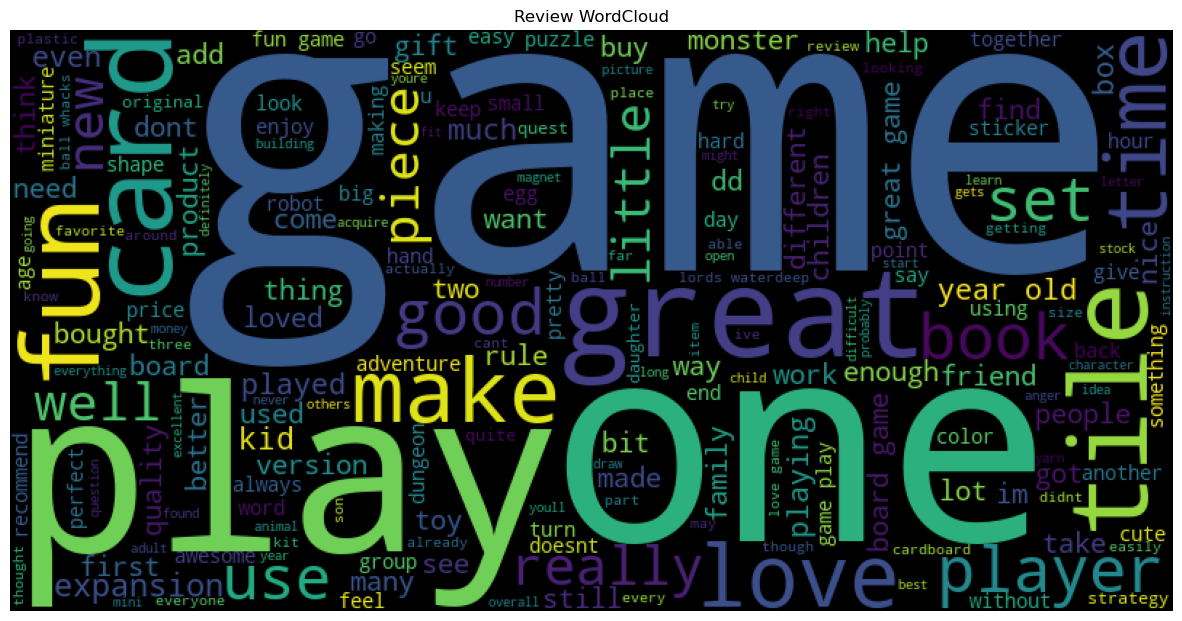

In [181]:
# Review: Create a word cloud.
# # Wordcloud: review
wc = WordCloud(width=800, height=400).generate(review_text_clean)
plt.imshow(wc)
plt.axis('off')
plt.title('Review WordCloud')
plt.show()

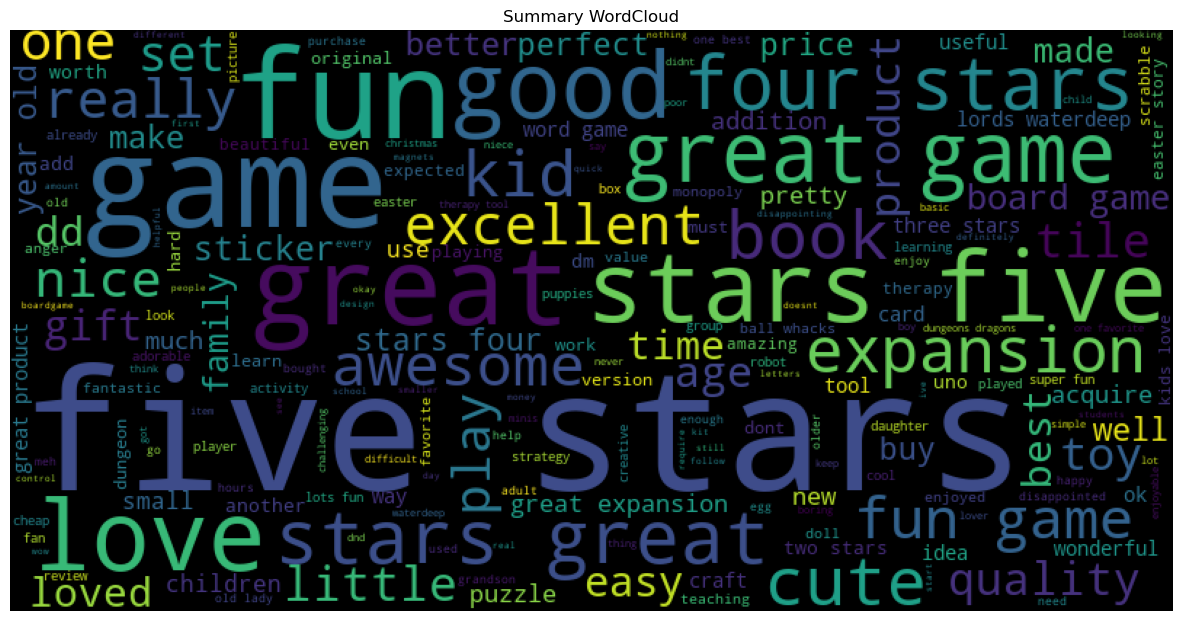

In [184]:
# Summary: Create a word cloud.
# Wordcloud: summary
wc2 = WordCloud(width=800, height=400).generate(summary_text_clean)
plt.imshow(wc2)
plt.axis('off')
plt.title('Summary WordCloud')
plt.show()

## 4. Frequency distribution and polarity
### 4a) Create frequency distribution

In [140]:
# Determine the frequency distribution.
# Frequency Distribution
freq = Counter(all_words)

### 4b) Remove alphanumeric characters and stopwords

In [185]:
# Delete all the stopwords.
stop_words = set(stopwords.words('english'))

In [189]:
# Remove all the stopwords
## Recreating user defined functions to remove stop words
def tokenise(text):
    words = re.findall(r'\b[a-z]+\b', text)
    words = [w for w in words if w not in stop_words]
    return words

## Apply to DataFrame
df4['review_tokens'] = df4['review_clean'].apply(tokenise)
df4['summary_tokens'] = df4['summary_clean'].apply(tokenise)

### 4c) Create wordcloud without stopwords

In [192]:
# Create a wordcloud without stop words.
## Convert back to text
df4['review_no_stop'] = df4['review_tokens'].apply(lambda x: ' '.join(x))
df4['summary_no_stop'] = df4['review_tokens'].apply(lambda x: ' '.join(x))

In [193]:
# Remove all the stopwords: using this for wordcloud
review_text = ' '.join(df4['review_no_stop'])

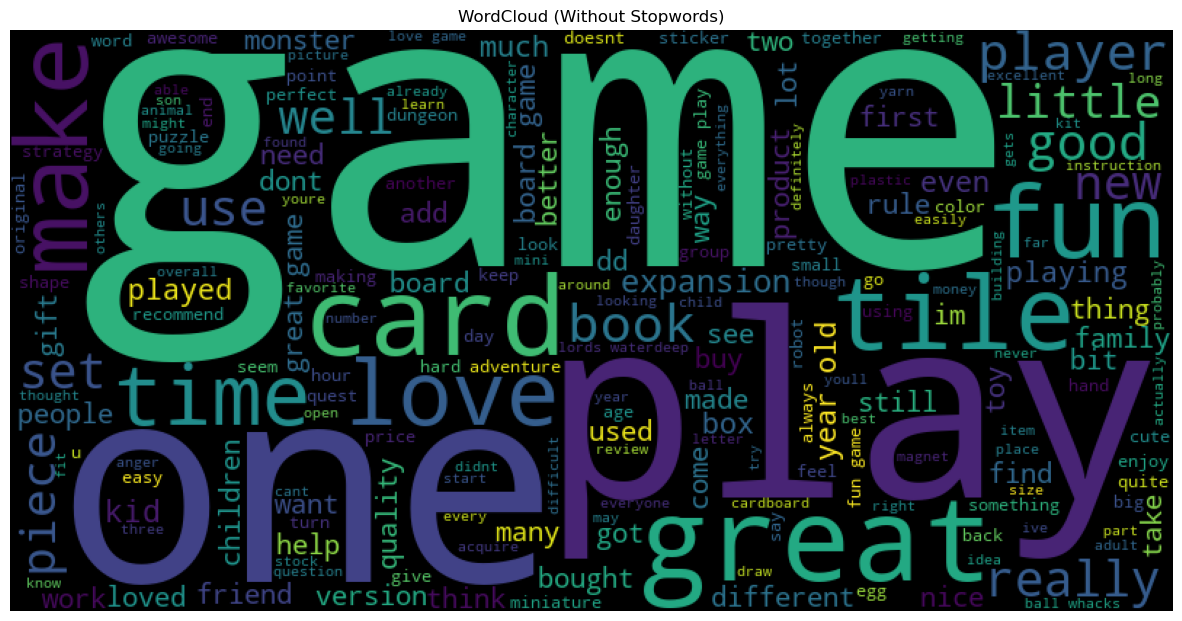

In [196]:
# Plot the wordcloud image.
wc = WordCloud(width=800, height=400).generate(review_text)


plt.imshow(wc)
plt.axis('off')
plt.title('WordCloud (Without Stopwords)')
plt.show()

### 4d) Identify 15 most common words and polarity

In [197]:
# Determine the 15 most common words.

# Top 15 words
top_15 = freq.most_common(15)
print(top_15)

[('game', 1671), ('great', 580), ('fun', 552), ('one', 530), ('play', 502), ('like', 414), ('love', 323), ('really', 319), ('get', 319), ('cards', 301), ('tiles', 297), ('time', 291), ('good', 289), ('would', 280), ('book', 273)]


## 5. Review polarity and sentiment: Plot histograms of polarity (use 15 bins) and sentiment scores for the respective columns.

In [146]:
# Provided function.
def generate_polarity(comment):
    '''Extract polarity score (-1 to +1) for each comment'''
    return TextBlob(comment).sentiment[0]

In [198]:
# Determine polarity of both columns. 
df4['review_polarity'] = df4['review_clean'].apply(generate_polarity)
df4['summary_polarity'] = df4['summary_clean'].apply(generate_polarity)

# View output.
print(df4['review_polarity'])
print(df4['summary_polarity'])

0      -0.036111
1       0.035952
2       0.116640
3       0.578788
4      -0.316667
          ...   
1995    0.168750
1996    0.158333
1997    0.200000
1998   -0.050000
1999   -0.095833
Name: review_polarity, Length: 1961, dtype: float64
0       0.150000
1      -0.800000
2       0.000000
3       0.000000
4       0.000000
          ...   
1995    0.200000
1996    0.316667
1997    0.200000
1998    0.000000
1999    0.050000
Name: summary_polarity, Length: 1961, dtype: float64


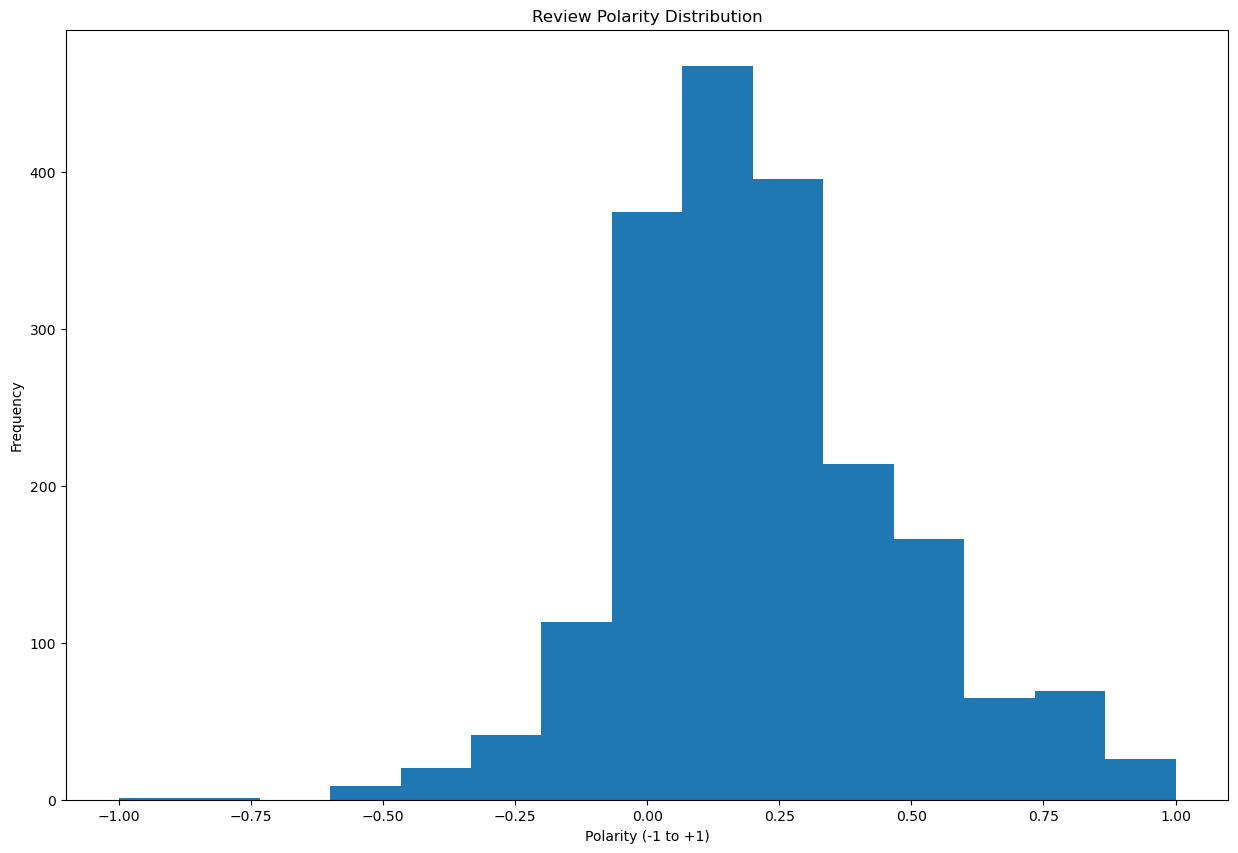

In [148]:
# Review: Create a histogram plot with bins = 15.
# Histogram of polarity
plt.hist(df4['review_polarity'], bins=15)
plt.title('Review Polarity Distribution')
plt.xlabel('Polarity (-1 to +1)')
plt.ylabel('Frequency')
plt.show()


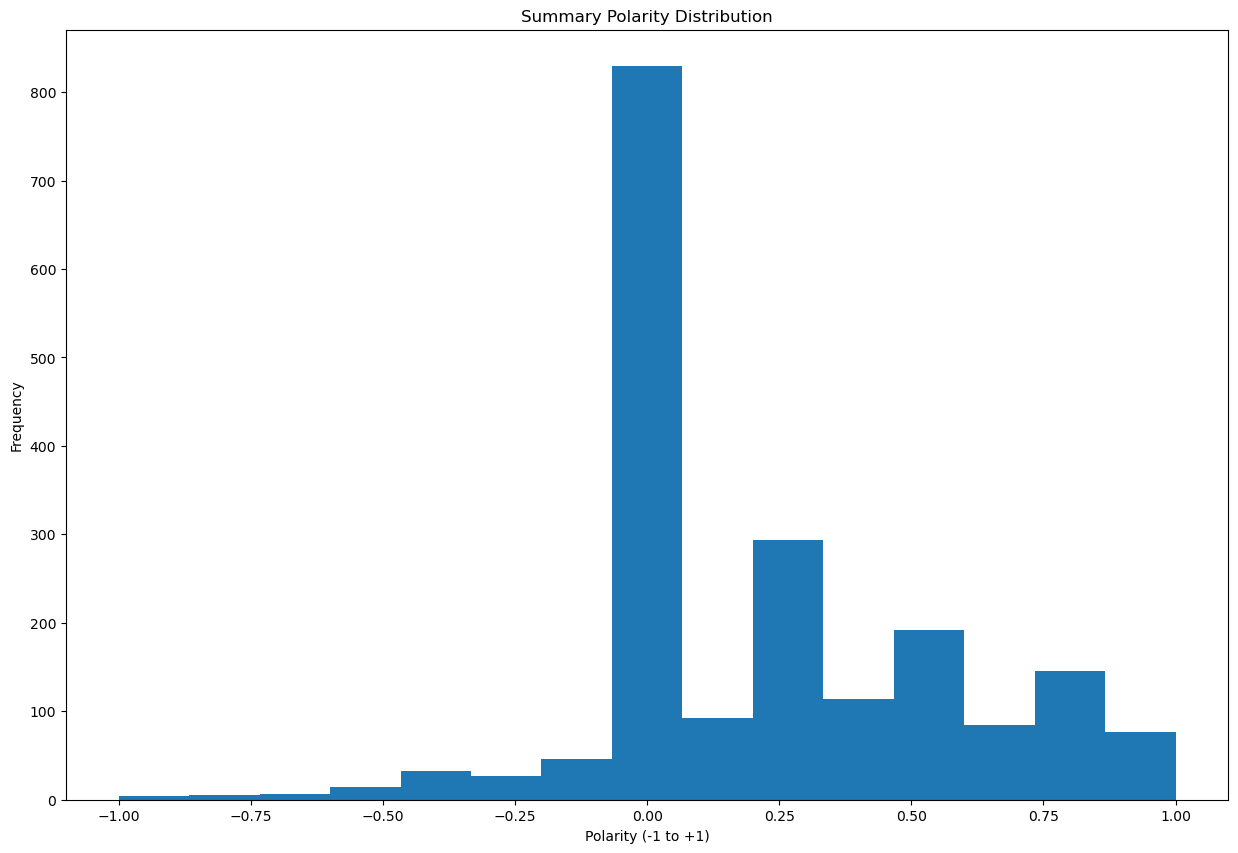

In [149]:
# Summary: Create a histogram plot with bins = 15.
# Histogram of polarity
plt.hist(df4['summary_polarity'], bins=15)
plt.title('Summary Polarity Distribution')
plt.xlabel('Polarity (-1 to +1)')
plt.ylabel('Frequency')
plt.show()


## 6. Identify top 20 positive and negative reviews and summaries respectively

In [150]:
# Top 20 negative reviews.
negative_reviews = df4.sort_values(by='review_polarity').head(20)

# View output.
print('\nTop Negative Reviews:')
print(negative_reviews[['review', 'review_polarity']])


Top Negative Reviews:
                                                 review  review_polarity
208   booo  unles you are patient know how to measur...        -1.000000
182                  incomplete kit  very disappointing        -0.780000
1804  im sorry i just find this product to be boring...        -0.583333
364   one of my staff will be using this game soon s...        -0.550000
1524                         expensive for what you get        -0.500000
117   i bought this as a christmas gift for my grand...        -0.500000
230                    i found the directions difficult        -0.500000
290              instructions are complicated to follow        -0.500000
301                                           difficult        -0.500000
227   this was a gift for my daughter  i found it di...        -0.500000
174   i sent this product to my granddaughter the po...        -0.491667
347   my 8 yearold granddaughter and i were very fru...        -0.446250
538   i purchased this on th

In [151]:
# Top 20 negative summaries.
negative_summaries = df4.sort_values(by='summary_polarity').head(20)

# View output.
print('\nTop Negative Summaries:')
print(negative_reviews[['summary', 'summary_polarity']])




Top Negative Summaries:
                                               summary  summary_polarity
208   boring unless you are a craft person which i am              -1.00
182                                     incomplete kit              0.00
1804                                     disappointing             -0.60
364                                 anger control game             -0.55
1524                                         two stars              0.00
117                                           stickers              0.00
230                                        three stars              0.00
290                                          two stars              0.00
301                                        three stars              0.00
227                                          two stars              0.00
174                                     faulty product              0.00
347                                         frustating              0.00
538                       

In [152]:
# Top 20 positive reviews.
positive_reviews = df4.sort_values(by='review_polarity', ascending=False).head(20)

# View output
print('Top Positve Reviews:')
print(positive_reviews[['review', 'review_polarity']])



Top Positve Reviews:
                                                 review  review_polarity
790                                             perfect              1.0
1726                  excellent toy to simulate thought              1.0
194                                        awesome gift              1.0
1967       perfect for tutoring my grandson in spelling              1.0
1177               awesome addition to my rpg gm system              1.0
1168               best set buy 2 if you have the means              1.0
524                         perfect just what i ordered              1.0
1715                                        awesome toy              1.0
1720  it is the best thing to play with and also min...              1.0
621   wonderful for my grandson to learn the resurre...              1.0
1135                                        awesome set              1.0
1609  this was perfect to go with the 7 bean bags  i...              1.0
1401  one of the best board ga

In [153]:
# Top 20 positive summaries.
positive_summaries = df4.sort_values(by='summary_polarity', ascending=False).head(20)

# View output
print('Top Positve Summaries:')
print(positive_reviews[['summary', 'summary_polarity']])


Top Positve Summaries:
          summary  summary_polarity
790   aquire game              -0.4
1726   five stars               0.0
194    five stars               0.0
1967     tutoring               0.0
1177   five stars               0.0
1168   five stars               0.0
524    five stars               0.0
1715   five stars               0.0
1720  three stars               0.0
621    five stars               0.0
1135   five stars               0.0
1609   five stars               0.0
1401   five stars               0.0
609    five stars               0.0
1301   five stars               0.0
7      five stars               0.0
165    five stars               0.0
591    five stars               0.0
933    five stars               0.0
496    five stars               0.0


## 7. Discuss: Insights and observations

***Your observations here...***

**Observations from Review Polarity Histograms**

- Most values are above 0 (i.e. within the positive range)
- There appears peak concentration around 0 to ~0.3
- There is spread into higher positive values (0.5 to 1.0)
- There are very few strongly negative values (< -0.5)
**Interpretation**
The distribution of review polarity is skewed towards positive values, with majority scores falling between 0 and 0.3.
This indicates that most customer reviews are mildly positive sentiment rather than extreme opinions.


**Insight**
- Customers show moderate satisfaction.
- The presence of high positive values show that happy customers exist.
- The small negative tail indicates limited dissatisfaction.

**Observations from Summary Polarity Histogram**

- Very strong concentration around 0 (neutral) and then spread into positive values (0.2 to 0.8).
- There are few negative values
- Here, the distribution is more compressed than Reviews distribution.
  
**Insight**
This indicates that, Summaries tend to be more balanced or less expressive compared to full reviews.

**KEY INSIGHT & BUSINESS USEFULNESS**
In comparison to reviews, summaries show higher concentration of neutral sentiment which suggest that customers compress
their opinions into more objective statements. For business decision-making, reviews are more useful for understanding customer
emotions and identifying specific issues, whereas summaries provide a general overview of customer sentiment.
In general, this sentiment analysis reveals that customer feedback is predominantly positive, however, there are few negative
sentiment which the organisation gas to address.


# 